# Prediction Market Overreaction Detector — Data Collection Pipeline

This notebook:
1. Loads and processes Kalshi contract price history from a local CSV
2. Collects and embeds financial news headlines from GDELT for each trading day using an N-day lookback window
3. Assembles a feature tensor combining embeddings, sentiment, and price data

Run cells top-to-bottom. Heavy steps are cached to `./data/` so reruns are fast.

## Section 0: Install Dependencies

In [59]:
import sys

# Packages without cp314 wheels for their pinned versions are left unpinned
# so uv resolves a release that ships a pre-built wheel for this interpreter.
# ipywidgets is required for tqdm's notebook progress bars.
!uv pip install -q --python "{sys.executable}" \
    pandas==2.2.3 \
    matplotlib \
    gdeltdoc==1.2.0 \
    sentence-transformers \
    transformers \
    torch \
    tqdm==4.67.1 \
    numpy \
    ipywidgets

## Section 1: Config & Setup

In [ ]:
import os
import sys
from datetime import datetime, timezone, timedelta

# ── Configurable parameters ────────────────────────────────────────────────────
N_DAY_WINDOW       = 6                          # lookback window in calendar days
KALSHI_CSV_PATH    = "./data/kalshi_contract.csv"
NEWS_KEYWORDS      = [
    "federal reserve",
    "interest rate",
    "rate cut",
    "rate hike",
    "Powell",
    "monetary policy",
]
EMBEDDING_MODEL    = "all-MiniLM-L6-v2"
SENTIMENT_MODEL    = "ProsusAI/finbert"
GDELT_SLEEP_S      = 6.0   # GDELT enforces ≥5 s between requests; 6 s gives headroom
GDELT_RETRIES      = 4     # retry attempts per failed chunk query
GDELT_BATCH_DAYS   = 7     # calendar days per GDELT chunk (weekly batches)
GDELT_BATCH_CACHE  = "./data/gdelt_batch_cache.json"   # {date_str: [title, ...]}
FEATURES_OUT       = "./data/features.pkl"

# GDELT only indexes the trailing ~3 months from today (92 days is a safe approximation)
GDELT_CUTOFF_DATE = datetime.now(timezone.utc).replace(tzinfo=None) - timedelta(days=92)
GDELT_CUTOFF_DATE = GDELT_CUTOFF_DATE.replace(hour=0, minute=0, second=0, microsecond=0)
# ──────────────────────────────────────────────────────────────────────────────

os.makedirs("./data", exist_ok=True)
print("Config loaded. ./data/ directory ready.")
print(f"GDELT cutoff date (rows before this are dropped): {GDELT_CUTOFF_DATE.date()}")

## Section 2: Load Kalshi CSV

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Guard: check that the CSV exists before going further ─────────────────────
if not os.path.exists(KALSHI_CSV_PATH):
    print(
        "\n⚠️  Kalshi CSV not found!"
        f"\n   Expected: {os.path.abspath(KALSHI_CSV_PATH)}"
        "\n"
        "\n   Please place your Kalshi price-history CSV at that path."
        "\n   The file should have (at minimum) two columns:"
        "\n     • a date/timestamp column  (e.g. 'timestamp' in ISO-8601 format)"
        "\n     • a closing price column   (e.g. 'close' or a contract-name column)"
        "\n"
        "\n   One easy way: export the daily price history from Kalshi's website"
        "\n   and drop the resulting CSV into ./data/kalshi_contract.csv"
    )
    sys.exit(1)

# ── Load raw CSV ──────────────────────────────────────────────────────────────
raw_df = pd.read_csv(KALSHI_CSV_PATH)
print("Raw columns:", list(raw_df.columns))
print("\nFirst few rows:")
display(raw_df.head())

Raw columns: ['timestamp', 'Fed maintains rate']

First few rows:


,timestamp,Fed maintains rate
0,2025-10-16T00:00:00Z,51.00
1,2025-11-30T00:00:00Z,62.69
2,2025-12-02T00:00:00Z,49.83
3,2025-12-06T00:00:00Z,48.01
4,2025-12-10T00:00:00Z,54.66


In [62]:
import pandas as pd

def normalize_kalshi_df(raw: pd.DataFrame) -> pd.DataFrame:
    """
    Normalize whatever column layout Kalshi exports into a clean DataFrame
    with columns: [date, close_price, daily_change].

    Strategy:
      - The first column is assumed to be the timestamp.
      - The second column is assumed to be the price series
        (works whether Kalshi names it 'close', a contract title, etc.).
    """
    df = raw.copy()

    date_col  = df.columns[0]
    price_col = df.columns[1]

    df["date"]        = pd.to_datetime(df[date_col], utc=True).dt.normalize().dt.tz_localize(None)
    df["close_price"] = pd.to_numeric(df[price_col], errors="coerce")

    df = (
        df[["date", "close_price"]]
        .dropna(subset=["close_price"])
        .sort_values("date")
        .reset_index(drop=True)
    )

    # Day-over-day price difference; first row gets NaN → fill 0
    df["daily_change"] = df["close_price"].diff().fillna(0)

    return df


kalshi_df = normalize_kalshi_df(raw_df)

# ── Drop rows outside GDELT's ~3-month accessible window ─────────────────────
cutoff = pd.Timestamp(GDELT_CUTOFF_DATE)
before = len(kalshi_df)
kalshi_df = kalshi_df[kalshi_df["date"] >= cutoff].reset_index(drop=True)
print(f"GDELT cutoff filter: dropped {before - len(kalshi_df)} row(s) before "
      f"{cutoff.date()} ({len(kalshi_df)} rows remaining)")

# Derive START_DATE / END_DATE from the data itself
START_DATE = kalshi_df["date"].min()
END_DATE   = kalshi_df["date"].max()

print("\nClean Kalshi DataFrame:")
display(kalshi_df.head())
print(f"\nDate range : {START_DATE.date()} → {END_DATE.date()}")
print(f"Trading days: {len(kalshi_df)}")
print(f"Close price — min: {kalshi_df.close_price.min():.2f}  "
      f"max: {kalshi_df.close_price.max():.2f}  "
      f"mean: {kalshi_df.close_price.mean():.2f}")

# Largest single-day moves
top_moves = kalshi_df.reindex(
    kalshi_df["daily_change"].abs().nlargest(5).index
)[["date", "close_price", "daily_change"]]
print("\nLargest single-day moves:")
display(top_moves)

GDELT cutoff filter: dropped 24 row(s) before 2026-01-13 (65 rows remaining)

Clean Kalshi DataFrame:


,date,close_price,daily_change
0,2026-01-13,72.94,1.98
1,2026-01-14,72.75,-0.19
2,2026-01-15,73.36,0.61
3,2026-01-16,75.71,2.35
4,2026-01-17,78.76,3.05



Date range : 2026-01-13 → 2026-03-18
Trading days: 65
Close price — min: 72.75  max: 99.00  mean: 89.64

Largest single-day moves:


,date,close_price,daily_change
30,2026-02-12,88.63,9.22
16,2026-01-29,89.96,7.84
10,2026-01-23,82.21,4.73
24,2026-02-06,86.09,-4.00
31,2026-02-13,92.18,3.55


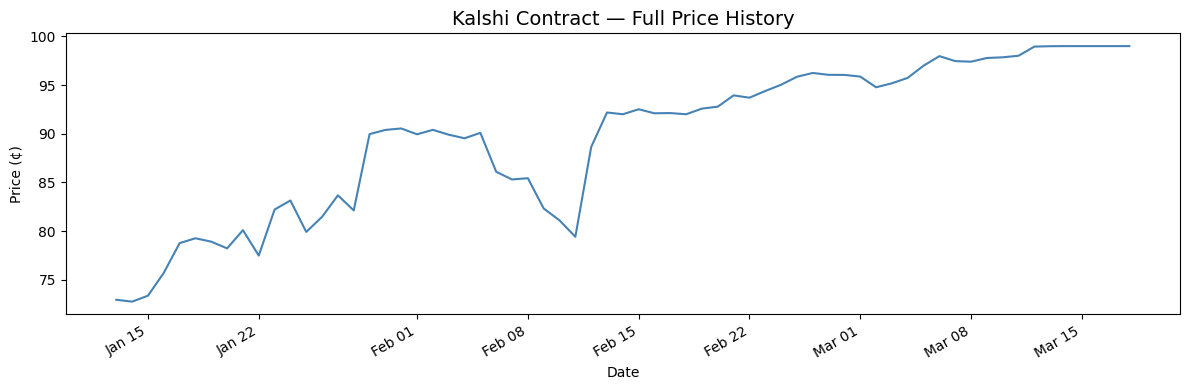

In [63]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(kalshi_df["date"], kalshi_df["close_price"], linewidth=1.5, color="steelblue")
ax.set_title("Kalshi Contract — Full Price History", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price (¢)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Section 3: GDELT News Collection

In [67]:
import json
import time
import requests
from urllib.parse import quote_plus

GDELT_BASE_URL = "https://api.gdeltproject.org/api/v2/doc/doc"


def build_weekly_chunks(
    range_start: pd.Timestamp,
    range_end: pd.Timestamp,
    chunk_days: int = GDELT_BATCH_DAYS,
):
    """Yield (chunk_start, chunk_end) pairs that tile [range_start, range_end]."""
    cur = range_start
    while cur <= range_end:
        yield cur, min(cur + timedelta(days=chunk_days - 1), range_end)
        cur += timedelta(days=chunk_days)


def fetch_gdelt_chunk(
    chunk_start: pd.Timestamp,
    chunk_end: pd.Timestamp,
) -> list[dict]:
    """
    Query GDELT DOC API for articles in [chunk_start, chunk_end].
    Returns a list of {title: str, date: pd.Timestamp} dicts (deduplicated).
    Logs the full URL and a response preview on every attempt so failures are
    easy to diagnose.
    """
    # GDELT requires OR'd terms to be wrapped in parentheses
    query_str = "(" + " OR ".join(f'"{kw}"' for kw in NEWS_KEYWORDS) + ")"
    url = (
        f"{GDELT_BASE_URL}"
        f"?query={quote_plus(query_str)}"
        f"&mode=artlist"
        f"&format=json"
        f"&STARTDATETIME={chunk_start.strftime('%Y%m%d000000')}"
        f"&ENDDATETIME={chunk_end.strftime('%Y%m%d235959')}"
        f"&maxrecords=250"
    )
    print(f"  [GDELT] chunk {chunk_start.date()} → {chunk_end.date()}")
    print(f"  [GDELT] URL: {url}")

    for attempt in range(1, GDELT_RETRIES + 1):
        try:
            resp = requests.get(url, timeout=30)
            print(f"  [GDELT] attempt {attempt}: status={resp.status_code}  "
                  f"preview={resp.text[:300]!r}")

            if resp.status_code == 429:
                wait = 10 * attempt
                print(f"  [GDELT] 429 rate-limited — waiting {wait}s")
                time.sleep(wait)
                continue

            resp.raise_for_status()

            if not resp.text.strip():
                print("  [GDELT] empty body — returning []")
                return []

            data = resp.json()
            articles = data.get("articles") or []

            results, seen = [], set()
            for art in articles:
                title    = (art.get("title") or "").strip()
                seendate = art.get("seendate") or art.get("date") or ""
                if not title or title.lower() in seen:
                    continue
                seen.add(title.lower())
                # seendate format: "20260115T120000Z"; fall back to chunk_start
                try:
                    art_date = pd.to_datetime(seendate[:8], format="%Y%m%d").normalize()
                except Exception:
                    art_date = chunk_start
                results.append({"title": title, "date": art_date})

            print(f"  [GDELT] got {len(results)} unique articles")
            return results

        except Exception as exc:
            print(f"  [GDELT] attempt {attempt}/{GDELT_RETRIES} failed: {exc}")
            if attempt < GDELT_RETRIES:
                # Sleep at least GDELT_SLEEP_S so we never violate the 5s rate limit
                time.sleep(max(GDELT_SLEEP_S, 2 ** attempt))

    return []

In [ ]:
from tqdm.auto import tqdm

trading_days = kalshi_df["date"].tolist()

# ── Load existing batch cache (per-day headlines) ─────────────────────────────
if os.path.exists(GDELT_BATCH_CACHE):
    with open(GDELT_BATCH_CACHE) as fh:
        per_day_headlines: dict[str, list[str]] = json.load(fh)
    print(f"Loaded batch cache from {GDELT_BATCH_CACHE} ({len(per_day_headlines)} day entries).")
else:
    per_day_headlines = {}
    print("No batch cache found — will query GDELT.")

# ── Compute the full calendar range needed (trading days + lookback) ──────────
# Clamp range_start to GDELT_CUTOFF_DATE — GDELT cannot serve older articles.
# Window days before the cutoff will produce empty headlines (zero vectors).
range_start = max(
    min(trading_days) - timedelta(days=N_DAY_WINDOW - 1),
    pd.Timestamp(GDELT_CUTOFF_DATE),
)
range_end = max(trading_days)

all_needed: list[pd.Timestamp] = []
cur = range_start
while cur <= range_end:
    all_needed.append(cur)
    cur += timedelta(days=1)

missing_days = [d for d in all_needed if str(d.date()) not in per_day_headlines]
print(f"Full range : {range_start.date()} → {range_end.date()} "
      f"({len(all_needed)} calendar days)")
print(f"Already cached : {len(all_needed) - len(missing_days)} days")
print(f"Need to fetch  : {len(missing_days)} days")

# ── Batch-query GDELT in weekly chunks ───────────────────────────────────────
if missing_days:
    chunk_range_start = missing_days[0]
    chunk_range_end   = missing_days[-1]
    chunks = list(build_weekly_chunks(chunk_range_start, chunk_range_end))
    print(f"\nQuerying {len(chunks)} weekly chunk(s) "
          f"(vs. {len(missing_days)} individual-day calls).")

    for chunk_start, chunk_end in tqdm(chunks, desc="Batch GDELT queries"):
        articles = fetch_gdelt_chunk(chunk_start, chunk_end)

        # Distribute articles into per_day_headlines by their seendate
        for art in articles:
            day_key = str(art["date"].date())
            per_day_headlines.setdefault(day_key, [])
            if art["title"] not in per_day_headlines[day_key]:
                per_day_headlines[day_key].append(art["title"])

        # Stamp every day in the chunk as seen (even days with zero articles)
        # so we don't re-query them on the next run.
        cur = chunk_start
        while cur <= chunk_end:
            per_day_headlines.setdefault(str(cur.date()), [])
            cur += timedelta(days=1)

        time.sleep(GDELT_SLEEP_S)

    with open(GDELT_BATCH_CACHE, "w") as fh:
        json.dump(per_day_headlines, fh, indent=2)
    print(f"\nBatch cache saved to {GDELT_BATCH_CACHE}.")
else:
    print("All days already cached — no GDELT queries needed.")

# ── Derive gdelt_results (windowed view, used by histogram in Section 5) ──────
gdelt_results: dict[pd.Timestamp, list[str]] = {}
for trade_date in trading_days:
    window_titles, seen = [], set()
    for offset in range(N_DAY_WINDOW):
        day_key = str((trade_date - timedelta(days=offset)).date())
        for t in per_day_headlines.get(day_key, []):
            if t.lower() not in seen:
                seen.add(t.lower())
                window_titles.append(t)
    gdelt_results[trade_date] = window_titles

print(f"\nBuilt gdelt_results for {len(gdelt_results)} trading days from local cache.")

In [ ]:
# ── Summary statistics for GDELT collection ───────────────────────────────────
article_counts = {d: len(gdelt_results.get(d, [])) for d in trading_days}
total_unique   = sum(article_counts.values())
avg_per_window = total_unique / max(len(trading_days), 1)
zero_days      = [d for d, cnt in article_counts.items() if cnt == 0]

print(f"Total article-window pairs collected : {total_unique}")
print(f"Average articles per window          : {avg_per_window:.1f}")
print(f"Trading days with zero articles      : {len(zero_days)}")
if zero_days:
    print("  ⚠️  Zero-article dates (will use zero vectors):")
    for d in zero_days:
        print(f"     {d.date()}")

## Section 4: Headline Embedding & Sentiment

In [ ]:
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

# ── Load models ───────────────────────────────────────────────────────────────
print(f"Loading embedding model: {EMBEDDING_MODEL}")
embedder = SentenceTransformer(EMBEDDING_MODEL)
EMBEDDING_DIM = embedder.get_sentence_embedding_dimension()
print(f"  Embedding dimension: {EMBEDDING_DIM}")

print(f"\nLoading sentiment model: {SENTIMENT_MODEL}")
sentiment_tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_MODEL)
sentiment_model     = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_MODEL)
sentiment_model.eval()
print("  FinBERT loaded. Labels: positive / negative / neutral")

In [ ]:
# ── Embedding helpers ─────────────────────────────────────────────────────────

def embed_headlines(headlines: list[str]) -> np.ndarray:
    """
    Compute the mean sentence embedding for a list of headlines.
    Returns a 1-D array of shape (EMBEDDING_DIM,).
    If the list is empty, returns a zero vector.
    """
    if not headlines:
        return np.zeros(EMBEDDING_DIM, dtype=np.float32)
    vecs = embedder.encode(headlines, show_progress_bar=False, convert_to_numpy=True)
    return vecs.mean(axis=0).astype(np.float32)


def sentiment_scores(headlines: list[str], batch_size: int = 16) -> np.ndarray:
    """
    Run FinBERT on each headline and average the softmax probabilities.
    Returns a 1-D array [p_positive, p_negative, p_neutral].
    If the list is empty, returns uniform (1/3, 1/3, 1/3).

    FinBERT label order: 0=positive, 1=negative, 2=neutral
    """
    UNIFORM = np.array([1/3, 1/3, 1/3], dtype=np.float32)
    if not headlines:
        return UNIFORM

    all_probs = []
    for i in range(0, len(headlines), batch_size):
        batch = headlines[i : i + batch_size]
        enc = sentiment_tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            max_length=128,
            padding=True,
        )
        with torch.no_grad():
            logits = sentiment_model(**enc).logits
        probs = F.softmax(logits, dim=-1).numpy()  # shape (batch, 3)
        all_probs.append(probs)

    return np.vstack(all_probs).mean(axis=0).astype(np.float32)  # (3,)


def build_day_features(
    day: pd.Timestamp,
    headlines: list[str],
    price_change: float,
) -> np.ndarray:
    """
    Combine embedding + sentiment + price_change into a single feature vector.
    Shape: (EMBEDDING_DIM + 3 + 1,)
    """
    emb  = embed_headlines(headlines)              # (EMBEDDING_DIM,)
    sent = sentiment_scores(headlines)             # (3,)
    pc   = np.array([price_change], dtype=np.float32)  # (1,)
    return np.concatenate([emb, sent, pc])         # (D,)

In [ ]:
# per_day_headlines and gdelt_results were fully built during the batch query
# in Section 3 — no additional GDELT queries needed here.
#
# Confirm that every window-day for every trading day has a cache entry.
total_window_days   = len(trading_days) * N_DAY_WINDOW
covered_window_days = sum(
    1
    for trade_date in trading_days
    for offset in range(N_DAY_WINDOW)
    if str((trade_date - timedelta(days=offset)).date()) in per_day_headlines
)
print(f"Per-day headline coverage: {covered_window_days}/{total_window_days} window-days cached")

zero_days = [
    trade_date for trade_date in trading_days
    if not any(
        per_day_headlines.get(str((trade_date - timedelta(days=offset)).date()))
        for offset in range(N_DAY_WINDOW)
    )
]
if zero_days:
    print(f"  ⚠️  {len(zero_days)} trading day(s) have zero articles across their entire window:")
    for d in zero_days:
        print(f"     {d.date()}")
else:
    print("  All trading-day windows have at least one article.")

In [ ]:
# ── Build feature tensors for every trading day ───────────────────────────────
FEATURE_DIM = EMBEDDING_DIM + 3 + 1  # embedding + sentiment + price_change
dataset: list[dict] = []
zero_vector_days: list[tuple[pd.Timestamp, pd.Timestamp]] = []  # (trade_date, window_day)

for _, row in tqdm(kalshi_df.iterrows(), total=len(kalshi_df), desc="Building features"):
    trade_date   = row["date"]
    close_price  = row["close_price"]
    daily_change = row["daily_change"]

    # Collect one feature vector per day in the lookback window
    # Window: [trade_date - (N-1) days, ..., trade_date]
    window_features: list[np.ndarray] = []

    for offset in reversed(range(N_DAY_WINDOW)):  # oldest → newest
        window_day  = trade_date - timedelta(days=offset)
        day_key     = str(window_day.date())
        headlines   = per_day_headlines.get(day_key, [])

        # Look up that window-day's price change from kalshi_df (if available)
        price_row = kalshi_df[kalshi_df["date"] == window_day]
        w_price_change = float(price_row["daily_change"].iloc[0]) if not price_row.empty else 0.0

        if not headlines:
            zero_vector_days.append((trade_date, window_day))

        feat = build_day_features(window_day, headlines, w_price_change)
        window_features.append(feat)

    feature_tensor = np.stack(window_features, axis=0)  # (N_DAY_WINDOW, FEATURE_DIM)
    dataset.append({
        "date"         : trade_date,
        "features"     : feature_tensor,
        "price"        : close_price,
        "daily_change" : daily_change,
    })

print(f"\nBuilt {len(dataset)} samples. Feature tensor shape per sample: "
      f"({N_DAY_WINDOW}, {FEATURE_DIM})")
print(f"Zero-vector days (no headlines): {len(zero_vector_days)}")

In [ ]:
import pickle

with open(FEATURES_OUT, "wb") as fh:
    pickle.dump(dataset, fh)

print(f"Dataset saved to {FEATURES_OUT}")
print(f"  Samples        : {len(dataset)}")
print(f"  Feature shape  : {dataset[0]['features'].shape}  (N_DAY_WINDOW × FEATURE_DIM)")

## Section 5: Data Validation & Summary

In [ ]:
import random

# ── Overall shape report ──────────────────────────────────────────────────────
n_samples, (n_win, n_feat) = len(dataset), dataset[0]["features"].shape
print("=" * 60)
print(f"Final dataset summary")
print("=" * 60)
print(f"  Number of samples  : {n_samples}")
print(f"  Window size        : {n_win} days")
print(f"  Feature dim / day  : {n_feat}  "
      f"({EMBEDDING_DIM} embed + 3 sentiment + 1 price_Δ)")
print(f"  Full tensor shape  : ({n_samples}, {n_win}, {n_feat})")

In [ ]:
# ── Spot-check 3 random samples ───────────────────────────────────────────────
spot_indices = random.sample(range(len(dataset)), min(3, len(dataset)))

for idx in spot_indices:
    sample = dataset[idx]
    trade_date = sample["date"]
    print("\n" + "─" * 60)
    print(f"Sample idx={idx}  |  Trade date: {trade_date.date()}")
    print(f"  Close price  : {sample['price']:.2f}¢")
    print(f"  Daily change : {sample['daily_change']:+.2f}¢")

    # Show headlines and sentiment for each day in the window
    for offset in range(N_DAY_WINDOW):
        window_day = trade_date - timedelta(days=N_DAY_WINDOW - 1 - offset)
        day_key    = str(window_day.date())
        headlines  = per_day_headlines.get(day_key, [])
        feat_row   = sample["features"][offset]

        # Last 3 elements: sentiment triplet; element before that: price_change
        price_feat = feat_row[-4]
        sent_feat  = feat_row[-3:]  # [pos, neg, neu]

        print(f"\n  Window day [{offset}]: {window_day.date()} "
              f"({len(headlines)} headlines)")
        print(f"    Sentiment  pos={sent_feat[0]:.3f}  "
              f"neg={sent_feat[1]:.3f}  neu={sent_feat[2]:.3f}")
        for h in headlines[:3]:  # show at most 3 example headlines
            print(f"    • {h[:100]}")
        if len(headlines) > 3:
            print(f"    … and {len(headlines) - 3} more")

In [ ]:
# ── Histogram: article counts per window ──────────────────────────────────────
window_counts = [len(gdelt_results.get(s["date"], [])) for s in dataset]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(window_counts, bins=20, color="steelblue", edgecolor="white", linewidth=0.5)
ax.set_title("Distribution of Article Counts per N-day Window", fontsize=13)
ax.set_xlabel("Number of articles in window")
ax.set_ylabel("Number of trading days")
ax.axvline(x=0.5, color="red", linestyle="--", linewidth=1, label="Zero-article threshold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nWindow coverage stats:")
print(f"  Min articles/window  : {min(window_counts)}")
print(f"  Max articles/window  : {max(window_counts)}")
print(f"  Mean articles/window : {sum(window_counts)/len(window_counts):.1f}")
print(f"  Zero-article windows : {sum(1 for c in window_counts if c == 0)}")